In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [2]:
df_2020 = pd.read_csv('data/nuremberg_2020_20m_polygons.csv')
df_2021 = pd.read_csv('data/nuremberg_2021_20m_polygons.csv')

In [3]:
df_2020.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cell_id', 'cropland',
       'grassland', 'image_count', 'tree_cover', 'water', 'x', 'y', 'year',
       '.geo'],
      dtype='str')

In [4]:
df_2020.dtypes

system:index                int64
B11                       float64
B12                       float64
B2                        float64
B3                        float64
B4                        float64
B5                        float64
B6                        float64
B7                        float64
B8                        float64
bare_sparse_vegetation    float64
built_up                  float64
cell_id                       str
cropland                  float64
grassland                 float64
image_count                 int64
tree_cover                float64
water                     float64
x                         float64
y                         float64
year                        int64
.geo                          str
dtype: object

In [5]:
df_2020 = df_2020.drop(columns=['system:index', 'image_count', '.geo', 'year', 'cell_id'])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['system:index', 'image_count', '.geo', 'year', 'cell_id'])
df_2021 = df_2021.fillna(df_2021.mean())

In [6]:
# B1, B9, B10

In [ ]:
# mean_median_cols = [col for col in df_2020.columns if ('_median' in col)]
# excluded_bands = [col for col in df_2020 if not ('B1_' in col or 'B9_' in col or 'B8A' in col or 'B10_' in col)]

# df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
# df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'tree_cover',
    'grassland',
    'cropland',
    'water'
]


remaining_target = [
    'bare_sparse_vegetation'
]

# sel_col = excluded_bands
# df_2020 = df_2020[sel_col]
# df_2021 = df_2021[sel_col]

In [8]:
df_2020.columns

Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'x', 'y'],
      dtype='str')

In [9]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
# df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
# df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [10]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_train = df_2020[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_test = df_2021[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_test = df_2021[target_labels]

In [11]:
X_train.columns, y_train.columns

(Index(['B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'x', 'y', 'NDVI', 'EVI', 'NDWI',
        'MNDWI'],
       dtype='str'),
 Index(['built_up', 'tree_cover', 'grassland', 'cropland', 'water'], dtype='str'))

In [ ]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [13]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

base_learners = [
    ('xgb', XGBRegressor(
        n_estimators=789,
        learning_rate=0.03970073695782001,
        random_state=42,
        max_depth=15,
        gamma=1.0391440954448874,
        min_child_weight=13,
        reg_alpha=2.5063145700217895,
        reg_lambda=1.3677301006351343,
        colsample_bytree=0.6174545647503418,
        subsample=0.8900211377979158,
        n_jobs=-1
    )),
    ('rf', RandomForestRegressor(
        n_estimators=390,
        random_state=42,
        max_depth=9,
        min_samples_split=14,
        min_samples_leaf=8,
        max_features=0.6061272316154472,
        n_jobs=-1
    )),
    ('mlp', Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(220, 118, 133),
            activation='relu',
            solver='adam',
            alpha=0.007440054125108525,
            learning_rate_init=0.0012469151701727857,
            max_iter=500,
            random_state=42,
        ))
    ]))
]

meta_learner = LinearRegression()

stacking_model = MultiOutputRegressor(
    StackingRegressor(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5,
        n_jobs=-1
    )
)

# Evaluation
results = []
res = evaluate_regression_model("Stacking Regressor", stacking_model, X_train, X_test, y_train, y_test)
results.append(res)

--- Stacking Regressor ---
Train R2: 0.8363 | Test R2: 0.7601
Train RMSE: 0.1241 | Test RMSE: 0.1543



In [14]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Stacking Regressor,0.124067,0.15427,0.83632,0.760086


In [15]:
selected_labels = [
    'tree_cover', 'built_up', 'grassland', 'cropland',
    'bare_sparse_vegetation', 'water'
]

pd.DataFrame({'mean': df_2020[selected_labels].mean(), 'std': df_2020[selected_labels].std()})

,mean,std
tree_cover,0.366616,0.438404
built_up,0.368465,0.435704
grassland,0.122122,0.287768
cropland,0.107917,0.294285
bare_sparse_vegetation,0.023656,0.119428
water,0.011117,0.098643


,True_Dominant_Class,Pred_Dominant_Class,Match
0,grassland,tree_cover,False
1,tree_cover,tree_cover,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


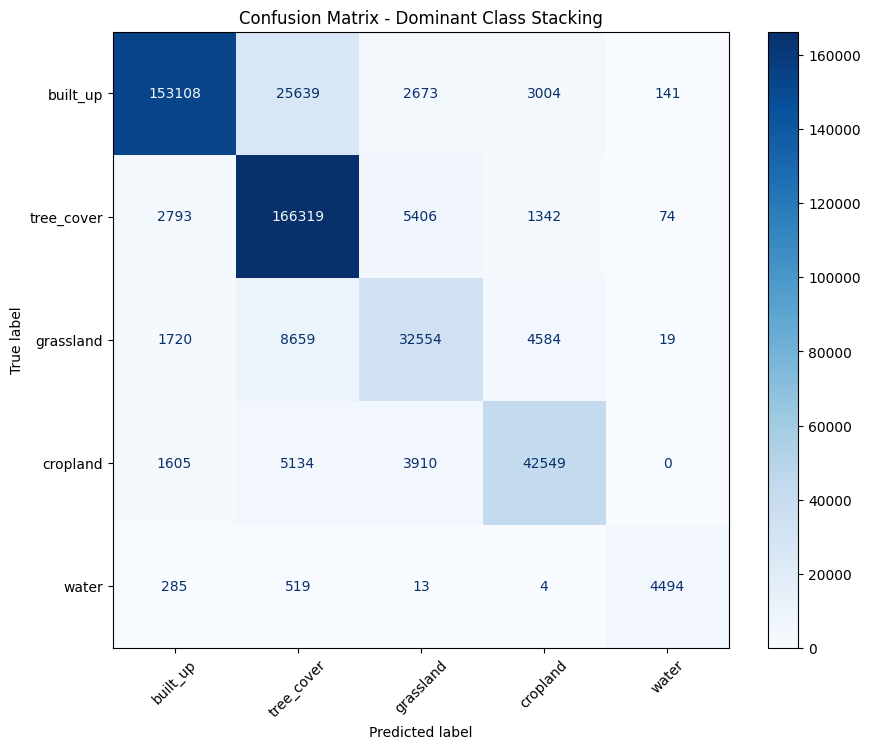

Overall Dominant Class Accuracy: 0.8553


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the labels actually used during training (4 labels in your current code)
current_labels = [
    # 'vegetation',
    'built_up',
    'tree_cover', 'grassland', 'cropland',
    # 'bare_sparse_vegetation',
    'water'
]

y_pred_array = stacking_model.predict(X_test)

# 2. Create DataFrame with the matching 4 columns
y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

# 3. Get dominant classes
true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

# 4. Build comparison table
comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

# 5. Output results
display(comparison_df.head(5))

# 6. Generate Confusion Matrix
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title('Confusion Matrix - Dominant Class Stacking')
plt.show()

accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")